# Does mirror temperature predict fiber loss? A worked example with `L_see`

This notebook is a worked, heavily-commented example of using the `telemetry_mining` package's
**`L_see`** attribute -- a per-exposure, artifact-free "how much light are we losing to bad seeing"
number -- to test a real physical hypothesis: *does the primary mirror running warmer than the
surrounding air make the delivered image quality worse?*

It's meant to be read top to bottom as a template for "pull a DB quantity, pull a derived
per-exposure metric, join them by `EXPID`, look for a relationship" -- one of the most common
patterns for a `telemetry_mining` study. Every step explains not just *what* the code does but
*why* it's written that way.

**The punchline, if you want it up front:** yes -- exposures where the mirror is warmer than the
air show measurably more fiber loss, and the effect is asymmetric (worse for a *warm* mirror than
for a *cool* one), exactly as the physics of mirror seeing predicts.

> **Kernel:** run this under the **DESI Master** kernel. `L_see` is computed with `desimodel`
> (`FastFiberAcceptance`), which the generic *NERSC Python* kernel does **not** have -- and the
> failure is silent: `L_see` would return `None` for *every* exposure with no error, not a crash.

## Background: what is `L_see`, and why not just use `RCALIBFRAC`?

DESI's standard-star flux ratio `RCALIBFRAC` (roughly, "measured flux / model flux" for a
calibration star) is the obvious way to ask "how much light is a fiber losing," and for a long
time that's exactly what studies used. The trouble is that a separate investigation (see
`docs/DAR_FIBER_LOSS_REPORT.md` in this repo if you want the full story) found that `RCALIBFRAC`
carries a **sky-subtraction artifact** baked in by an early pipeline stage -- it isn't purely a
statement about fiber acceptance, it's contaminated by something that has nothing to do with the
optics or the atmosphere.

`L_see` is the artifact-free replacement for the *level* part of that signal. It's built entirely
from **guide-camera (GFA) imaging** -- which never touches the sky-subtracted spectroscopic flux at
all -- so it structurally cannot carry that artifact. The definition:

$$L_\mathrm{see} = 1 - \frac{A(\sigma, 0)}{A(\sigma_\mathrm{ref}, 0)}$$

where $A(\sigma, \delta)$ is DESI's fiber-acceptance function (`desimodel`'s
`FastFiberAcceptance`, evaluated at PSF size $\sigma$ and fiber-to-star offset $\delta$), evaluated
at *perfect centering* ($\delta=0$) so only the seeing (PSF-size) contribution shows up -- no
guiding/pointing effects mixed in. $\sigma_\mathrm{ref}$ is a fixed 1.1&Prime; reference seeing (the
same fixed value `desispec`'s own pipeline already assumes elsewhere), so **`L_see` is a *relative*
loss**: positive means "worse than 1.1&Prime; seeing," negative means "better than 1.1&Prime;."
**Expect a good fraction of any sample to be negative** -- that simply means the seeing was better
than the 1.1&Prime; reference, not that anything is wrong. `L_see` is defined and fixed in
`docs/FIBER_LOSS_METRICS.md`; this notebook just consumes it.

There's a sibling metric, **`L_field`**, that captures the spatial *pattern* of DAR-driven loss
across the focal plane (not used in this notebook, but see `docs/FIBER_LOSS_METRICS.md` if your
question is about the shape of the loss field rather than its overall level).

In [3]:
import sys
from pathlib import Path
# Point this at your own telemetry_mining checkout if you're running this notebook somewhere else
# (svn co https://desi.lbl.gov/svn/code/online/telemetry_mining/trunk).
TM_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
sys.path.insert(0, str(TM_ROOT / "src"))
from telemetry_mining.config import Config
from telemetry_mining.exposure import Exposure
from telemetry_mining import gfa, fiber_loss
cfg = Config.default()

print("gfa_root :", cfg.gfa_root)
print("path     :", gfa._gfa_summary_path(cfg))
try:
    df = gfa.load_gfa_summary(cfg, refresh=True)
    print("rows:", len(df), "| index:", df.index.name, "| 348386 in:", 348386 in df.index,
          "| FWHM_ASEC col:", "FWHM_ASEC" in df.columns)
except Exception as e:
    print("load raised:", repr(e))

exp = Exposure(348386, config=cfg)
print("gfa_row None:", exp.gfa_row is None, "| _gfa_fwhm:", exp._gfa_fwhm(),
      "| l_see_from_fwhm(1.0):", fiber_loss.l_see_from_fwhm(1.0), "| L_see:", exp.L_see)

gfa_root : /global/cfs/cdirs/desi/survey/GFA
path     : /global/cfs/cdirs/desi/survey/GFA/offline_matched_coadd_ccds_main-thru_20260808.fits
rows: 36815 | index: EXPID | 348386 in: True | FWHM_ASEC col: True
gfa_row None: False | _gfa_fwhm: 0.9408294057845021 | l_see_from_fwhm(1.0): None | L_see: None


In [2]:
import sys
from pathlib import Path

# Point this at your own telemetry_mining checkout if you're running this notebook somewhere else
# (svn co https://desi.lbl.gov/svn/code/online/telemetry_mining/trunk).
TM_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
sys.path.insert(0, str(TM_ROOT / "src"))

import numpy as np
from telemetry_mining.config import Config
from telemetry_mining.exposure import Exposure
from telemetry_mining import gfa, fiber_loss
cfg = Config.default()

print("gfa_root :", cfg.gfa_root)
print("path     :", gfa._gfa_summary_path(cfg))
try:
    df = gfa.load_gfa_summary(cfg, refresh=True)
    print("rows:", len(df), "| index:", df.index.name, "| 348386 in:", 348386 in df.index,
          "| FWHM_ASEC col:", "FWHM_ASEC" in df.columns)
except Exception as e:
    print("load raised:", repr(e))

exp = Exposure(348386, config=cfg)
print("gfa_row None:", exp.gfa_row is None, "| _gfa_fwhm:", exp._gfa_fwhm(),
      "| l_see_from_fwhm(1.0):", fiber_loss.l_see_from_fwhm(1.0), "| L_see:", exp.L_see)
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from telemetry_mining import select_exposures
from telemetry_mining.config import Config
from telemetry_mining.exposure import Exposure

cfg = Config.default()
print("telemetry_mining ready.")

gfa_root : /global/cfs/cdirs/desi/survey/GFA
path     : /global/cfs/cdirs/desi/survey/GFA/offline_matched_coadd_ccds_main-thru_20260808.fits
rows: 36815 | index: EXPID | 348386 in: True | FWHM_ASEC col: True
gfa_row None: False | _gfa_fwhm: 0.9408294057845021 | l_see_from_fwhm(1.0): -0.10404326702283151 | L_see: -0.16560628636145824
telemetry_mining ready.


## The physical hypothesis: mirror seeing

DESI's primary mirror is a large mass of glass with a lot of thermal inertia. If it's warmer than
the surrounding air, the air in contact with it forms convective plumes -- exactly the shimmer you
see over a hot road -- and that turbulence sits right in the light path, degrading the delivered
PSF on top of whatever the atmosphere itself is doing. This is a well-known effect in the
ground-based optical-astronomy world, usually called **"mirror seeing."**

The prediction is directional and testable: define

$$\Delta T = T_\mathrm{mirror} - T_\mathrm{air}$$

If mirror seeing is real and matters, we expect `L_see` (our seeing-loss metric) to be
**flat-to-good for $\Delta T \le 0$** (mirror at or below air temperature -- no convective driver)
and to **climb for $\Delta T > 0$** (mirror warmer than air -- convection kicks in, and should get
worse the larger the excess). That asymmetry -- not just "any correlation" -- is the actual
signature we're looking for, and it's what makes this a good example: a flat, symmetric scatter
would *not* support the hypothesis even if it were noisy in an interesting-looking way.

## Step 1: the metric -- `Exposure(expid).L_see`

This is the point of the notebook: **`Exposure(expid).L_see` just works.** You don't need to know
that it's built from GFA seeing, you don't need `desimodel` installed and configured correctly (it
still works if it isn't -- more on that in a moment), and you don't need to care whether you're
running this at NERSC or (in the future) at KPNO.

Under the hood, `.L_see` tries a **direct computation** first (reads the offline GFA seeing
reconstruction for this exposure, runs it through `desimodel`'s fiber-acceptance model) and, only if
that isn't possible in your environment, **transparently falls back** to a precomputed lookup table
registered as a `TableSource`. This matters because the offline GFA reduction this metric depends on
is a NERSC-side product -- it doesn't exist yet at KPNO in real time. Rather than making every user
special-case "am I at KPNO or NERSC," the attribute hides that decision: same code, same result,
either site. (If you *are* at a site without the offline product and without a registered fallback
table, `.L_see` just returns `None` -- always check for that, as we do below.)

It really is just an attribute -- grab a single exposure and read it:

In [3]:
# The metric is just an attribute on an Exposure -- one exposure, one number.
demo = Exposure(348386, config=cfg)
print(f"L_see for exposure {demo.expid}: {demo.L_see}")

L_see for exposure 348386: -0.16560628636145824


## Step 2: build the study sample with `select_exposures`

Now we want that same number for a whole sample, joined to the mirror/air temperatures. The
idiomatic `telemetry_mining` way to do this is **one `select_exposures` call** rather than a raw SQL
query plus a hand-written loop: you give it a `WHERE` clause and a `columns` dict mapping each output
column to a *spec*, and it returns a tidy one-row-per-exposure DataFrame.

Two kinds of spec appear here, and the distinction is the whole reason this is one call and not two:

- **`"db_row.<column>"`** pulls a column straight from `exposure.exposure`. These are **free** --
  `select_exposures` already runs one bulk query for the `WHERE` filter, so every exposure-table
  field (here `airmass`, `totteff`, and the two `mirror_temp`/`air_temp` values inside the `telescope`
  `jsonb` blob) rides along on that single query. The temperatures live inside `jsonb`, so we read
  them with a small `lambda` on `db_row` rather than a dotted path.
- **a callable that computes per exposure** -- here `lambda e: e.L_see`, *the same attribute* from
  Step 1. `L_see` reads the nightly offline GFA *summary* file, which `telemetry_mining` loads **once
  and caches**, so across a whole sample this is a single file load plus a cheap per-exposure lookup
  -- fast in a single sequential pass. (`select_exposures` does take a `max_workers` argument for
  specs that genuinely cost a per-exposure round-trip -- e.g. a callable that queries `telemetry`
  once per exposure -- but `L_see` is *not* one of those, so there's nothing to parallelize here and
  we leave it sequential. For the *entire* survey, precompute a table with
  `scripts/build_fiber_loss_metrics.py` and join it directly.)

**The sample:** `sequence = 'DESI'` (only real science exposures, not focus/calibration sequences)
and `totteff > 300` (a minimum *effective* exposure time, DESI's SNR-weighted exposure-quality
measure -- filters out exposures that were cut short or never reached usable depth). We use
`totteff` rather than the simpler `exptime` because it is DESI's standard exposure-quality measure,
so results stay comparable across studies. (If you expect some specs to *raise* for certain
exposures -- e.g. a purged FITS file -- pass `on_error="skip"` and inspect `df.attrs["skipped"]`;
here `L_see` simply returns `None` when uncovered, so a plain `dropna` is enough.)

In [4]:
MIN_TOTTEFF = 300  # minimum effective exposure time (DESI's SNR-weighted exposure-quality measure)

joined = select_exposures(
    where="sequence = 'DESI' AND totteff > %s "
          "AND telescope ? 'mirror_temp' AND telescope ? 'air_temp'",
    params=(MIN_TOTTEFF,),
    columns={
        "airmass":     "db_row.airmass",                                  # free -- rides the bulk query
        "totteff":     "db_row.totteff",                                  # free
        "mirror_temp": lambda e: float(e.db_row["telescope"]["mirror_temp"]),  # jsonb field
        "air_temp":    lambda e: float(e.db_row["telescope"]["air_temp"]),     # jsonb field
        "L_see":       lambda e: e.L_see,                                 # the Step-1 attribute, per exposure
    },
    config=cfg,
    # No max_workers: L_see is a cheap lookup into a summary file that's loaded once and cached,
    # so a single sequential pass is already fast -- threading would only add overhead here.
)
joined["delta_T"] = joined["mirror_temp"] - joined["air_temp"]

# L_see is None when the offline GFA product doesn't cover this exposure (rare, but real -- always
# drop rather than silently coerce to NaN-and-forget).
n_before = len(joined)
joined = joined.dropna(subset=["L_see"]).copy()
print(f"{len(joined)}/{n_before} exposures have a valid L_see")
joined.head()

12824/12923 exposures have a valid L_see


,EXPID,NIGHT,airmass,totteff,mirror_temp,air_temp,L_see,delta_T
0,90131,20210528,1.098981,1014.0236,15.975,18.442,-0.007768,-2.467
1,90132,20210528,1.001490,431.2150,16.138,18.790,-0.140174,-2.652
2,90133,20210528,1.021066,1008.7112,16.312,18.977,-0.129040,-2.665
3,90134,20210528,1.003963,557.6871,16.500,19.193,-0.175793,-2.693
4,90234,20210529,1.248699,552.3630,15.975,17.225,0.346777,-1.250


## Step 3: is there a relationship at all?

Start with the simplest possible test -- a plain linear correlation over the whole sample -- before
reaching for anything fancier. This sets expectations for the plots that follow, and (as you'll
see) the answer here is a little bit of a trap if you stop reading at this cell.

In [5]:
x = joined["delta_T"].to_numpy()
y = joined["L_see"].to_numpy()

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)

print(f"n = {len(joined)}")
print(f"Pearson  r = {pearson_r:.4f}, p = {pearson_p:.3g}")
print(f"Spearman r = {spearman_r:.4f}, p = {spearman_p:.3g}")

n = 12824
Pearson  r = 0.0680, p = 1.25e-14
Spearman r = 0.0179, p = 0.0424


A Pearson `r` around 0.07 doesn't look like much on its own -- and if you only ran this
correlation and stopped, you might reasonably conclude the mirror-seeing effect is too weak to
bother with. **This is the trap:** our hypothesis was never "loss increases linearly with $\Delta T$
everywhere" -- it was "loss is flat for $\Delta T \le 0$ and climbs for $\Delta T > 0$." A single
linear correlation coefficient averages over the *whole* range and can't see an asymmetric,
one-sided effect for what it is. That's exactly why the next section bins the data instead of
just fitting a line.

## Step 4: visualize it properly

Two views of the same `(delta_T, L_see)` data, and they're deliberately different from each other:

1. **A 2-D density heatmap** (log-scaled color, since the point cloud is heavily concentrated near
   the middle and a linear color scale would hide everything but the single densest bin) shows the
   *raw* data honestly -- no binning choices hidden from the reader.
2. **A binned-means curve**, overlaid on the heatmap and also shown on its own, averages `L_see`
   within 20 equal-width bins of $\Delta T$ (error bars are the standard error of each bin's mean,
   `std / sqrt(n)`) -- this is what actually reveals the asymmetric trend the single correlation
   number above was blind to.

Showing both together (not just the flattering one) is the point: the heatmap keeps you honest
about how noisy the underlying data really is, and the binned curve shows you the structure your
eye can't extract from 10,000+ overlapping points on its own.

In [6]:
def binned_means(x, y, nbins=20):
    '''Mean +/- standard-error-of-the-mean of y in nbins equal-width bins of x.

    A bin is skipped if it has fewer than 5 points -- with too few points the standard error
    itself becomes unreliable, and an empty/near-empty bin just clutters the plot.
    '''
    edges = np.linspace(x.min(), x.max(), nbins + 1)
    bin_index = np.clip(np.digitize(x, edges) - 1, 0, nbins - 1)
    bx, by, bye = [], [], []
    for i in range(nbins):
        in_bin = bin_index == i
        if in_bin.sum() < 5:
            continue
        bx.append(0.5 * (edges[i] + edges[i + 1]))
        by.append(y[in_bin].mean())
        bye.append(y[in_bin].std() / np.sqrt(in_bin.sum()))
    return np.array(bx), np.array(by), np.array(bye)


bx, by, bye = binned_means(x, y, nbins=20)

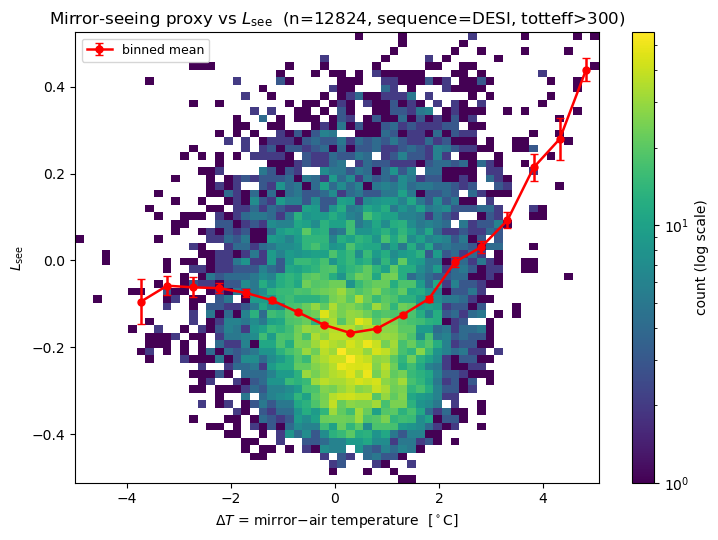

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# cmin=1 makes empty cells transparent instead of the darkest color, and LogNorm keeps the sparse
# outer regions visible instead of being swamped by the single densest central bin.
h = ax.hist2d(x, y, bins=60, cmap="viridis", cmin=1, norm=LogNorm())
cb = fig.colorbar(h[3], ax=ax)
cb.set_label("count (log scale)")

ax.errorbar(bx, by, yerr=bye, fmt="o-", color="red", lw=1.8, ms=5, capsize=3, label="binned mean")
ax.set_xlabel(r"$\Delta T$ = mirror$-$air temperature  [$^\circ$C]")
ax.set_ylabel(r"$L_\mathrm{see}$")
ax.set_title(f"Mirror-seeing proxy vs $L_\\mathrm{{see}}$  (n={len(joined)}, sequence=DESI, totteff>{MIN_TOTTEFF})")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

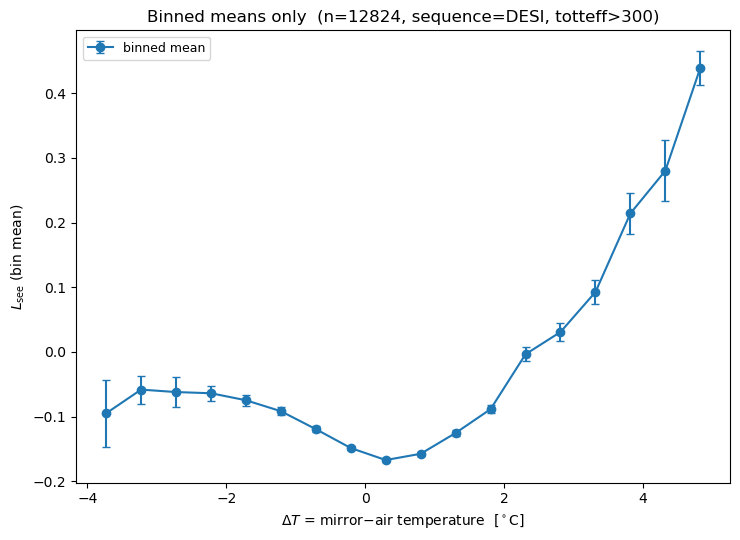

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.errorbar(bx, by, yerr=bye, fmt="o-", color="tab:blue", capsize=3, ms=6, label="binned mean")
ax.set_xlabel(r"$\Delta T$ = mirror$-$air temperature  [$^\circ$C]")
ax.set_ylabel(r"$L_\mathrm{see}$ (bin mean)")
ax.set_title(f"Binned means only  (n={len(joined)}, sequence=DESI, totteff>{MIN_TOTTEFF})")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Reading the result

The binned curve traces out an asymmetric V: it's close to flat (even mildly negative) for
$\Delta T \lesssim 1^\circ$C, and then **climbs steadily and monotonically** for warmer mirrors, all
the way out to the edge of the sample. That's exactly the signature the mirror-seeing hypothesis
predicted -- not a symmetric bowl (which could just as easily come from some unrelated variable that
happens to be extremal near $\Delta T\approx0$), but a specific one-sided rise on the *warm-mirror*
side.

**A caveat worth keeping explicit, in the spirit of not overselling a demo:** the steepest points
sit in the least-populated bins at the edge of the $\Delta T$ range. That doesn't make the trend
wrong, but it does mean the *exact slope* at the extreme end is less certain than the plot's tight
error bars alone might suggest -- a real follow-up analysis would want to check that with an
equal-*count* binning (rather than equal-width) and/or a check for confounding variables (e.g. does
the high-$\Delta T$ tail cluster on a handful of specific nights?) before treating the endpoint
value as precise. We're flagging this rather than fixing it here because the point of this notebook
is the *method*, not a publication-grade result.

## A note on negative `L_see`

Looking back at the `L_see` column, many of the values are *negative* -- expected, not a bug.
`L_see` is defined *relative* to a fixed 1.1&Prime; reference seeing (see "Background" above, and
`docs/FIBER_LOSS_METRICS.md`), so a negative value just means the seeing was **better than 1.1&Prime;**
-- less light lost than at the reference, a "gain" rather than a loss from some absolute zero. On a
night with typical DESI seeing comfortably under 1.1&Prime;, most exposures come out negative, and
that is exactly right.

## Summary and further reading

- **`Exposure(expid).L_see`** gives you an artifact-free, per-exposure seeing-loss level with no
  need to know how it's computed or whether you're at NERSC or KPNO.
- **`select_exposures`** builds the whole study frame in one call: `db_row.*` specs are free (they
  ride the single bulk query), and a cheap cached lookup like `L_see` needs no special handling --
  no raw SQL and no hand-written join loop. (`max_workers` is there for specs that cost a real
  per-exposure round-trip; `L_see` isn't one, so we leave it sequential.)
- Values are **relative to a fixed 1.1&Prime; reference seeing**, not an absolute zero -- negative
  values are a normal "better than reference" result, not an error.
- A single linear correlation can hide a real, physically-motivated **asymmetric** effect; binning
  (or an explicitly asymmetric model) can reveal it.
- This result -- fiber loss increases specifically when the mirror runs warmer than the air, more so
  the larger the excess -- both demonstrates the `L_see` API *and* is a genuine, physically
  interpretable finding in its own right.

**For more:**
- `docs/FIBER_LOSS_METRICS.md` -- full definitions of `L_see` and its sibling `L_field` (the
  spatial/DAR-pattern metric, not used in this notebook).
- `docs/DAR_FIBER_LOSS_REPORT.md` -- the investigation that motivated building artifact-free metrics
  in the first place.
- `scripts/build_fiber_loss_metrics.py` -- if you need `L_see`/`L_field` available somewhere the
  direct computation can't run (e.g. KPNO), this builds the fallback lookup table.